# Exploratory Data Analysis (EDA): Volleyball Spike Contact Timing

This notebook performs **exploratory data analysis (EDA)** for a computer vision project that aims to detect the **contact moment of a volleyball spike** using **multimodal signals**:

- **Pose motion** (e.g., wrist kinematics from video)
- **Audio impact** (short, high-energy sound at ball-hand contact)

## Goals

- Visualize pose keypoints over video frames
- Analyze **right wrist motion** and estimate a pose-based contact frame
- Inspect **audio impact** signals and estimate an audio-based contact time/frame
- Analyze **right hip trajectory** to estimate jump apex
- Compare the above signals to evaluate feasibility of contact detection

---

**Dataset structure (expected)**

```text
project_root/
    data/
        spike_clips/
            V3.mp4
            V4.mp4
```

If your local filenames differ, the notebook will automatically fall back to the first `.mp4` it can find under `data/spike_clips/`.

## 2. Import Libraries

This section imports the core libraries used throughout the EDA:

- OpenCV for video I/O
- MediaPipe Pose for keypoint estimation
- NumPy for time-series handling
- Matplotlib for visualization
- Librosa for audio loading and short-time energy analysis

In [18]:
%%bash

pip uninstall mediapipe
pip install mediapipe==0.10.13

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 41.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.


In [4]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import librosa

from pathlib import Path

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["image.cmap"] = "gray"

## 3. Load Video

We load a sample video from:

- `data/spike_clips/clip01.mp4`

If it does not exist locally, we fall back to the first `.mp4` under `data/spike_clips/`.

We print:

- FPS
- number of frames

In [7]:
from pathlib import Path

data_dir = Path("/content")
video_dir = data_dir / "spike_clips"

preferred_video = video_dir / "V3.mp4"

if preferred_video.exists():
    video_path = preferred_video
else:
    candidates = sorted(video_dir.glob("*.mp4")) if video_dir.exists() else []
    if not candidates:
        raise FileNotFoundError(
            "No videos found. Expected `.mp4` under `/content/spike_clips/`."
        )
    video_path = candidates[0]

video_path

PosixPath('/content/spike_clips/V3.mp4')

In [8]:
cap = cv2.VideoCapture(str(video_path))
if not cap.isOpened():
    raise RuntimeError(f"Failed to open video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Video: {video_path}")
print(f"Resolution: {width}x{height}")
print(f"FPS: {fps:.3f}")
print(f"Number of frames: {frame_count}")

Video: /content/spike_clips/V3.mp4
Resolution: 1920x1080
FPS: 30.000
Number of frames: 153


## 4. Extract Frames

We read the video frame-by-frame using OpenCV and store frames in a list.

Note: if your clips are longer, you can set `MAX_FRAMES` to a smaller number for faster iteration during EDA.

In [9]:
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

MAX_FRAMES = None  # e.g., 150 for quick EDA
frames_bgr = []

while True:
    if MAX_FRAMES is not None and len(frames_bgr) >= MAX_FRAMES:
        break

    ok, frame = cap.read()
    if not ok:
        break
    frames_bgr.append(frame)

cap.release()

print(f"Extracted frames: {len(frames_bgr)}")

Extracted frames: 153


## 5. Pose Estimation

We use **MediaPipe Pose** to extract body landmarks for each frame.

For each frame, we:

- detect pose
- store **RIGHT_WRIST** coordinates
- store **RIGHT_HIP** coordinates

Coordinates are stored in **pixel space**
(x = x_norm \(\times\) width, y = y_norm \(\times\) height).

If pose is not detected for a frame, we store `NaN` for that frame.

In [19]:
import mediapipe as mp
import mediapipe.python.solutions.pose as mp_pose

mp_pose = mp_pose
RIGHT_WRIST = mp_pose.PoseLandmark.RIGHT_WRIST
RIGHT_HIP = mp_pose.PoseLandmark.RIGHT_HIP

wrist_xy = np.full((len(frames_bgr), 2), np.nan, dtype=np.float32)
hip_xy = np.full((len(frames_bgr), 2), np.nan, dtype=np.float32)

pose_results = []  # keep results for optional debugging/visualization

with mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    enable_segmentation=False,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
) as pose:
    for i, frame_bgr in enumerate(frames_bgr):
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        res = pose.process(frame_rgb)
        pose_results.append(res)

        if not res.pose_landmarks:
            continue

        h, w = frame_bgr.shape[:2]
        lm = res.pose_landmarks.landmark

        rw = lm[RIGHT_WRIST]
        rh = lm[RIGHT_HIP]

        wrist_xy[i] = (rw.x * w, rw.y * h)
        hip_xy[i] = (rh.x * w, rh.y * h)

wrist_xy[:5], hip_xy[:5]

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


(array([[      nan,       nan],
        [      nan,       nan],
        [675.06445, 667.31024],
        [679.2817 , 660.7395 ],
        [680.75104, 661.63135]], dtype=float32),
 array([[      nan,       nan],
        [      nan,       nan],
        [707.1854 , 585.3614 ],
        [701.7609 , 584.2345 ],
        [698.55383, 583.79535]], dtype=float32))

## 6. Visualize Pose Overlay

We display one example frame with the MediaPipe pose skeleton overlay to sanity-check landmark quality.

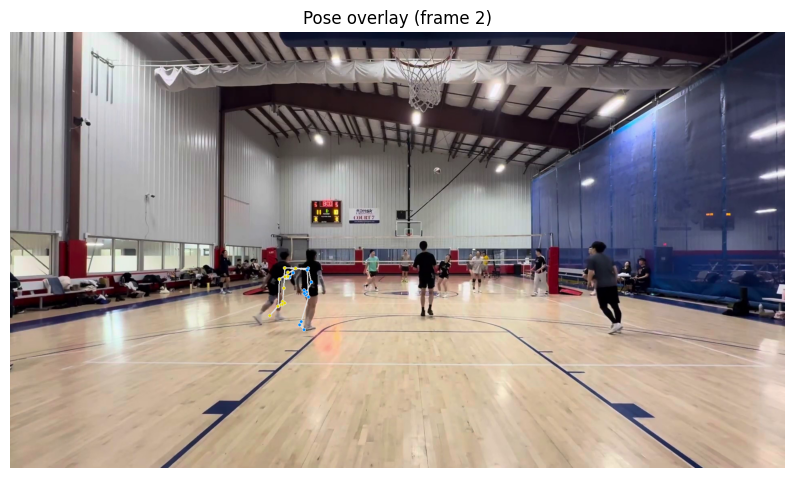

In [21]:
from mediapipe.python.solutions import drawing_utils as mp_drawing
from mediapipe.python.solutions import drawing_styles as mp_drawing_styles

# pick a frame with detected landmarks (fallback to 0)
valid_idx = np.where(~np.isnan(wrist_xy[:, 0]))[0]
example_idx = int(valid_idx[0]) if len(valid_idx) else 0

frame_bgr = frames_bgr[example_idx].copy()
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

res = pose_results[example_idx]
if res.pose_landmarks:
    mp_drawing.draw_landmarks(
        frame_rgb,
        res.pose_landmarks,
        mp_pose.POSE_CONNECTIONS,
        landmark_drawing_spec=mp_drawing_styles.get_default_pose_landmarks_style(),
    )

plt.figure(figsize=(10, 6))
plt.title(f"Pose overlay (frame {example_idx})")
plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

## 7. Wrist Velocity Analysis

We compute **right wrist velocity magnitude** across frames:

- Convert wrist positions to a NumPy array
- Compute frame-to-frame displacement
- Convert displacement to velocity magnitude (pixels/second)

We plot velocity vs. frame index and mark the frame with **maximum velocity** as a **pose-based contact estimate**.

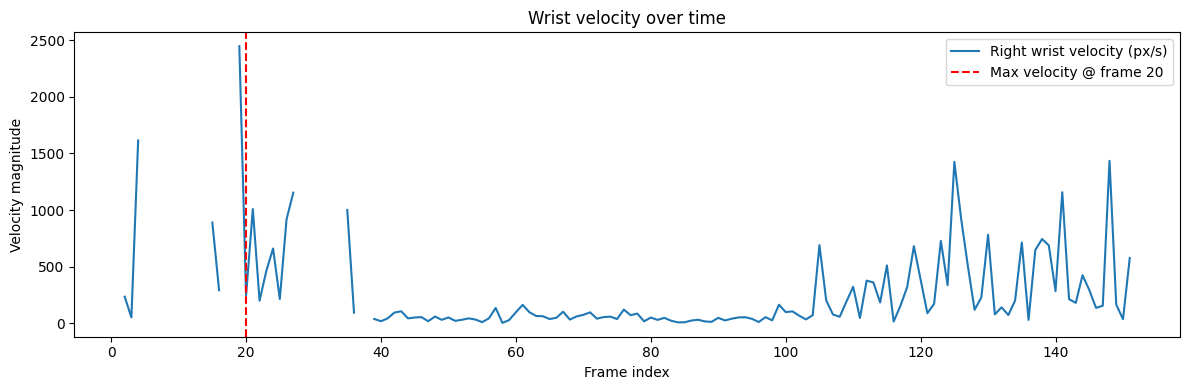

20

In [22]:
wrist = wrist_xy.astype(np.float32)

# Displacement between consecutive frames (NaNs propagate)
dw = np.diff(wrist, axis=0)

disp = np.linalg.norm(dw, axis=1)  # pixels per frame
vel = disp * (fps if fps and fps > 0 else 1.0)  # pixels per second

# Identify maximum velocity frame (ignore NaNs)
if np.all(np.isnan(vel)):
    pose_contact_frame = None
else:
    pose_contact_frame = int(np.nanargmax(vel) + 1)  # +1 because diff reduces length by 1

plt.figure(figsize=(12, 4))
plt.plot(vel, label="Right wrist velocity (px/s)")
plt.xlabel("Frame index")
plt.ylabel("Velocity magnitude")
plt.title("Wrist velocity over time")

if pose_contact_frame is not None:
    plt.axvline(pose_contact_frame, color="red", linestyle="--", label=f"Max velocity @ frame {pose_contact_frame}")

plt.legend()
plt.tight_layout()
plt.show()

pose_contact_frame

## 8. Hip Trajectory (Jump Apex)

We compute the **right hip y-trajectory** and use it as a simple jump proxy.

Because image coordinates increase downward, the **highest jump position** corresponds to **minimum y**.

We mark the frame where `hip_y` is minimal as the **jump apex**.

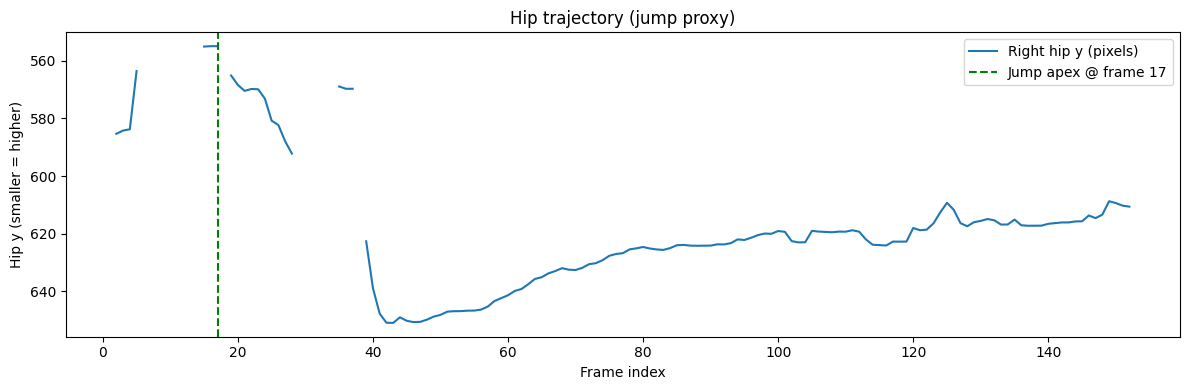

17

In [23]:
hip_y = hip_xy[:, 1].astype(np.float32)  # pixel y

if np.all(np.isnan(hip_y)):
    jump_apex_frame = None
else:
    jump_apex_frame = int(np.nanargmin(hip_y))

plt.figure(figsize=(12, 4))
plt.plot(hip_y, label="Right hip y (pixels)")
plt.xlabel("Frame index")
plt.ylabel("Hip y (smaller = higher)")
plt.title("Hip trajectory (jump proxy)")

if jump_apex_frame is not None:
    plt.axvline(jump_apex_frame, color="green", linestyle="--", label=f"Jump apex @ frame {jump_apex_frame}")

plt.gca().invert_yaxis()  # visually intuitive: higher on plot = higher jump
plt.legend()
plt.tight_layout()
plt.show()

jump_apex_frame

## 9. Audio Extraction

We load the audio track from the video using `librosa` and compute short-time energy using RMS.

We then:

- plot RMS energy vs time
- find the **highest energy peak**
- label this as an **audio-based contact estimate**

Note: Depending on your environment, loading audio from `.mp4` may require FFmpeg support via `audioread`. If audio loading fails, the cell will raise a helpful error message.

/tmp/ipykernel_26989/3561165307.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(str(video_path), sr=None, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


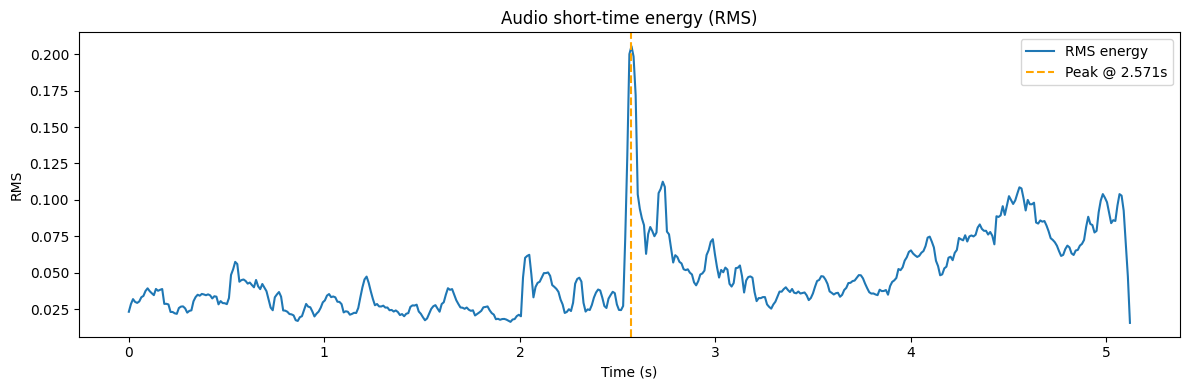

(241, 2.570666666666667, 77)

In [24]:
# Load audio from the video file
try:
    y, sr = librosa.load(str(video_path), sr=None, mono=True)
except Exception as e:
    raise RuntimeError(
        "Failed to load audio from the video. If you're on Linux/WSL, installing FFmpeg often helps. "
        "Original error:\n" + str(e)
    )

# RMS energy over short frames
hop_length = 512
frame_length = 2048

rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length, center=True)[0]
times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop_length)

peak_idx = int(np.argmax(rms)) if len(rms) else None
peak_time = float(times[peak_idx]) if peak_idx is not None else None

plt.figure(figsize=(12, 4))
plt.plot(times, rms, label="RMS energy")
plt.xlabel("Time (s)")
plt.ylabel("RMS")
plt.title("Audio short-time energy (RMS)")

if peak_time is not None:
    plt.axvline(peak_time, color="orange", linestyle="--", label=f"Peak @ {peak_time:.3f}s")

plt.legend()
plt.tight_layout()
plt.show()

# Map audio peak time to an estimated frame index
if peak_time is None or not (fps and fps > 0):
    audio_contact_index = None
else:
    audio_contact_index = int(round(peak_time * fps))

peak_idx, peak_time, audio_contact_index

## 10. Contact Detection Comparison

We compare three key timing estimates:

- `pose_contact_frame`: max wrist velocity frame (pose-based contact estimate)
- `audio_contact_index`: RMS peak mapped to a frame index (audio-based contact estimate)
- `jump_apex_frame`: minimum hip y frame (jump apex estimate)

These signals will later be **fused** in a multimodal pipeline for more robust contact timing detection.

In [25]:
print("pose_contact_frame:", pose_contact_frame)
print("audio_contact_index:", audio_contact_index)
print("jump_apex_frame:", jump_apex_frame)

if pose_contact_frame is not None and audio_contact_index is not None:
    print("pose - audio (frames):", pose_contact_frame - audio_contact_index)

if pose_contact_frame is not None and jump_apex_frame is not None:
    print("pose - apex (frames):", pose_contact_frame - jump_apex_frame)

if audio_contact_index is not None and jump_apex_frame is not None:
    print("audio - apex (frames):", audio_contact_index - jump_apex_frame)

pose_contact_frame: 20
audio_contact_index: 77
jump_apex_frame: 17
pose - audio (frames): -57
pose - apex (frames): 3
audio - apex (frames): 60


## 11. Summary

This exploratory analysis investigates whether key moments in a volleyball spike can be approximated using simple signals derived from video and audio data.

First, pose landmarks extracted with MediaPipe allow us to track the motion of relevant body joints. The velocity of the right wrist shows a clear peak during the spike sequence, which likely corresponds to the moment of maximum arm acceleration and potential ball contact.

Second, short-time audio energy (RMS) reveals a distinct spike around the same temporal region, suggesting that the impact sound between the hand and ball can serve as an additional cue for contact timing.

Finally, the vertical trajectory of the right hip provides a coarse estimate of jump dynamics. The minimum hip-y value corresponds to the jump apex, which typically occurs shortly before or near the spike motion in volleyball biomechanics.

Taken together, these observations suggest that combining pose-based motion features and audio energy signals provides a promising starting point for estimating spike contact timing. The heuristics developed in this notebook serve as a baseline multimodal analysis, which can be further refined and integrated into a more robust spike detection pipeline in later stages of the project.